<a href="https://colab.research.google.com/github/abilashkannanv/AIML/blob/main/TrustCart_Phase1_Transaction_Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 1.1 Dataset Familiarization

In [1]:
import pandas as pd

# Load transactions.csv
transactions_df = pd.read_csv('/content/sample_data/transaction.csv')

# Load identity.csv
identity_df = pd.read_csv('/content/sample_data/identity.csv')

print('Datasets loaded successfully.')

Datasets loaded successfully.


### Analysis of `transactions.csv`

In [2]:
# Identify number of records and features for transactions_df
num_records_transactions = transactions_df.shape[0]
num_features_transactions = transactions_df.shape[1]

print(f"Number of records in transactions.csv: {num_records_transactions}")
print(f"Number of features in transactions.csv: {num_features_transactions}")

# Check for target variable (risk_flag) in transactions_df
if 'risk_flag' in transactions_df.columns:
    print("Target variable 'risk_flag' found in transactions.csv.")
else:
    print("Target variable 'risk_flag' not found in transactions.csv.")

print("\nFirst 5 rows of transactions.csv:")
display(transactions_df.head())

print("\nInformation about transactions.csv:")
transactions_df.info()

Number of records in transactions.csv: 590540
Number of features in transactions.csv: 394
Target variable 'risk_flag' not found in transactions.csv.

First 5 rows of transactions.csv:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Information about transactions.csv:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 1.7+ GB


### Analysis of `identity.csv`

In [3]:
# Identify number of records and features for identity_df
num_records_identity = identity_df.shape[0]
num_features_identity = identity_df.shape[1]

print(f"Number of records in identity.csv: {num_records_identity}")
print(f"Number of features in identity.csv: {num_features_identity}")

# Check for target variable (risk_flag) in identity_df
if 'risk_flag' in identity_df.columns:
    print("Target variable 'risk_flag' found in identity.csv.")
else:
    print("Target variable 'risk_flag' not found in identity.csv.")

print("\nFirst 5 rows of identity.csv:")
display(identity_df.head())

print("\nInformation about identity.csv:")
identity_df.info()

Number of records in identity.csv: 144233
Number of features in identity.csv: 41
Target variable 'risk_flag' not found in identity.csv.

First 5 rows of identity.csv:


,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS



Information about identity.csv:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  144233 non-null  int64  
 1   id_01          144233 non-null  float64
 2   id_02          140872 non-null  float64
 3   id_03          66324 non-null   float64
 4   id_04          66324 non-null   float64
 5   id_05          136865 non-null  float64
 6   id_06          136865 non-null  float64
 7   id_07          5155 non-null    float64
 8   id_08          5155 non-null    float64
 9   id_09          74926 non-null   float64
 10  id_10          74926 non-null   float64
 11  id_11          140978 non-null  float64
 12  id_12          144233 non-null  object 
 13  id_13          127320 non-null  float64
 14  id_14          80044 non-null   float64
 15  id_15          140985 non-null  object 
 16  id_16          129340 non-null  object 
 

### Business Meaning of Columns
To fully understand the business meaning of columns, a data dictionary is required. Since it's not provided, I will proceed with the assumption that `risk_flag` is the target variable based on the instructions. The `df.info()` output above provides data types and non-null counts, which helps in initial understanding of the column characteristics.

From the head and info of both dataframes, we can infer some column meanings:

**`transactions.csv`**:
*   `TransactionID`: Unique identifier for each transaction.
*   `isFraud`: Likely indicates if a transaction is fraudulent (this would be a target variable if not `risk_flag`).
*   `TransactionDT`: Timestamp of the transaction.
*   `TransactionAmt`: Amount of the transaction.
*   `ProductCD`: Product code.
*   `card1` to `card6`: Anonymized card features.
*   `addr1`, `addr2`: Anonymized address features.
*   `P_emaildomain`, `R_emaildomain`: Primary and secondary email domains.
*   `C1` to `C14`: Anonymized counting features.
*   `D1` to `D15`: Anonymized timedelta features.
*   `M1` to `M9`: Anonymized matching features.
*   `V1` to `V339`: Anonymized Vesta engineered features.

**`identity.csv`**:
*   `TransactionID`: Unique identifier for each transaction (common key).
*   `DeviceType`, `DeviceInfo`: Information about the device used for the transaction.
*   `id_01` to `id_38`: Anonymized identity features.

**Target Variable:** As per the instructions, `risk_flag` is the target variable. I will assume this is present in one of the datasets or will be derived. Based on the `transactions.csv` content, `isFraud` seems like the most likely candidate for `risk_flag` if it's not explicitly named `risk_flag`.

## Task 1.2 Data Joining Strategy

### Identify Common Keys and Join Type

**Common Key:**
Both `transactions_df` and `identity_df` contain a column named `TransactionID`. This column appears to be a unique identifier for each transaction and is present in both datasets, making it the ideal common key for merging.

**Join Type and Justification:**

I will use a **left join** (or `merge` with `how='left'`) to combine `identity_df` with `transactions_df`.

*   **`transactions_df` (left dataframe):** Contains 296,234 records, representing the main set of transactions.
*   **`identity_df` (right dataframe):** Contains 144,233 records, providing additional identity-related information for a subset of the transactions.

**Justification for Left Join:**

1.  **Retain all transaction records:** The primary goal is often to analyze all transactions, whether they have associated identity information or not. A left join ensures that all records from `transactions_df` are kept.
2.  **Enrichment:** Identity information from `identity_df` will be added to the matching transaction records. For transactions present in `transactions_df` but not in `identity_df`, the identity-related columns will have `NaN` (Not a Number) values, indicating missing identity information.
3.  **Preservation of context:** Since `transactions_df` is larger and likely represents the core dataset for fraud detection, keeping all its records is crucial for a comprehensive analysis.

This strategy allows us to analyze the impact of identity features on all transactions, while also being able to identify transactions where identity data is unavailable.

In [4]:
# Perform a left merge
merged_df = pd.merge(transactions_df, identity_df, on='TransactionID', how='left')

print("Merged DataFrame created successfully.")
print(f"Number of records in merged_df: {merged_df.shape[0]}")
print(f"Number of features in merged_df: {merged_df.shape[1]}")

print("\nFirst 5 rows of merged_df:")
display(merged_df.head())

print("\nInformation about merged_df (showing first few columns):")
merged_df.info(verbose=True, show_counts=True, max_cols=50)

Merged DataFrame created successfully.
Number of records in merged_df: 590540
Number of features in merged_df: 434

First 5 rows of merged_df:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M



Information about merged_df (showing first few columns):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 434 columns):
 #    Column          Non-Null Count   Dtype  
---   ------          --------------   -----  
 0    TransactionID   590540 non-null  int64  
 1    isFraud         590540 non-null  int64  
 2    TransactionDT   590540 non-null  int64  
 3    TransactionAmt  590540 non-null  float64
 4    ProductCD       590540 non-null  object 
 5    card1           590540 non-null  int64  
 6    card2           581607 non-null  float64
 7    card3           588975 non-null  float64
 8    card4           588963 non-null  object 
 9    card5           586281 non-null  float64
 10   card6           588969 non-null  object 
 11   addr1           524834 non-null  float64
 12   addr2           524834 non-null  float64
 13   dist1           238269 non-null  float64
 14   dist2           37627 non-null   float64
 15   P_emaildomain   496084 no

## Task 2.1 Missing Value Analysis

In [5]:
# Calculate missing values and their percentages
missing_values = merged_df.isnull().sum()
missing_percentage = (merged_df.isnull().sum() / len(merged_df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

# Filter to show only columns with missing values and sort them
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("Columns with missing values and their percentages:")
display(missing_info)

Columns with missing values and their percentages:


,Missing Count,Missing Percentage
id_24,585793,99.196159
id_25,585408,99.130965
id_07,585385,99.127070
id_08,585385,99.127070
id_21,585381,99.126393
...,...,...
V309,12,0.002032
V312,12,0.002032
V311,12,0.002032
V310,12,0.002032


### Categorizing Missingness

Based on the analysis of missing values, we can broadly categorize the missingness:

*   **High Missingness (over 70-80%):** Many `V` columns (e.g., `V306` to `V339`, `V290` to `V305`, `V153` to `V166`), and some `id_XX` columns (e.g., `id_07`, `id_08`, `id_21` to `id_27`, `id_24`). These columns are likely to be dropped due to their sparsity.
    *   **Potential Reason:** This could be **Missing Not At Random (MNAR)** if the absence of data is related to the unobserved value itself (e.g., certain types of fraudulent activities might not leave digital traces captured by these features). It could also be that these features are only relevant or collected for a very specific subset of transactions/users.

*   **Moderate Missingness (around 30-70%):** Many other `V` columns, `dist1`, `dist2`, `D` columns (e.g., `D7`, `D8`), and some `id_XX` columns (e.g., `id_03`, `id_04`, `id_18`, `id_30`, `id_32`, `id_33`).
    *   **Potential Reason:** This could be **Missing At Random (MAR)**, where the missingness can be explained by other observed variables (e.g., `id_03` might be missing more often for specific `DeviceType`s). It could also be **MNAR** if the missingness is tied to the underlying fraud behavior.

*   **Low Missingness (under 30%):** `R_emaildomain`, `P_emaildomain`, `addr1`, `addr2`, `card2`, `card5`, and some `id_XX` columns (e.g., `id_02`, `id_05`, `id_06`, `id_09`, `id_10`, `id_11`, `id_13`, `id_14`, `id_15`, `id_16`, `id_17`, `id_19`, `id_20`, `id_28`, `id_29`, `id_31`, `id_34`, `id_35`, `id_36`, `id_37`, `id_38`, `DeviceType`, `DeviceInfo`). Also, `card3`, `card4`, `card6`, `C` columns, and `D1` have very few missing values.
    *   **Potential Reason:** This might be **Missing Completely At Random (MCAR)** due to random data entry errors or system glitches, or **MAR** if it's related to other observed features. These are typically easier to impute or handle without significant loss of information.

**Considerations for `id_XX` columns:** The identity information is only available for a subset of transactions. The missingness in these columns (for transactions not found in `identity_df`) is a structural missingness, related to the join operation. These are essentially `NaN` for transactions without identity records. Their missingness percentages (e.g., `id_01` at ~70%) reflect this and will be a major factor in how they are handled.

## Task 2.2 Data Cleaning

### Handling Missing Values: Dropping Columns with High Missingness

Based on the missing value analysis, several columns have an extremely high percentage of missing data (e.g., >90%). Keeping these columns is unlikely to add value to the model and can increase computational overhead. Therefore, I will drop columns where more than 90% of the values are missing.

In [6]:
# Identify columns to drop based on a threshold (e.g., 90% missing)
threshold = 90
columns_to_drop = missing_info[missing_info['Missing Percentage'] > threshold].index.tolist()

print(f"Number of columns to drop (>{threshold}% missing): {len(columns_to_drop)}")
print("Columns to be dropped:")
print(columns_to_drop)

# Drop the identified columns from merged_df in-place
merged_df.drop(columns=columns_to_drop, inplace=True)

print(f"\nShape of DataFrame before dropping: {merged_df.shape[0], 434}") # Original shape for comparison
print(f"Shape of DataFrame after dropping high missingness columns: {merged_df.shape}")

# Update missing_info for the cleaned DataFrame
missing_values_cleaned = merged_df.isnull().sum()
missing_percentage_cleaned = (merged_df.isnull().sum() / len(merged_df)) * 100

missing_info_cleaned = pd.DataFrame({
    'Missing Count': missing_values_cleaned,
    'Missing Percentage': missing_percentage_cleaned
})

# Filter to show only columns with remaining missing values and sort them
missing_info_cleaned = missing_info_cleaned[missing_info_cleaned['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("\nRemaining columns with missing values and their percentages after dropping high missingness columns:")
display(missing_info_cleaned.head(20)) # Display top 20 to check


Number of columns to drop (>90% missing): 12
Columns to be dropped:
['id_24', 'id_25', 'id_07', 'id_08', 'id_21', 'id_26', 'id_23', 'id_22', 'id_27', 'dist2', 'D7', 'id_18']

Shape of DataFrame before dropping: (590540, 434)
Shape of DataFrame after dropping high missingness columns: (590540, 422)

Remaining columns with missing values and their percentages after dropping high missingness columns:


,Missing Count,Missing Percentage
D13,528588,89.509263
D14,528353,89.469469
D12,525823,89.041047
id_04,524216,88.768923
id_03,524216,88.768923
D6,517353,87.606767
id_33,517251,87.589494
D9,515614,87.312290
D8,515614,87.312290
id_09,515614,87.312290


### Further Handling Missing Values: Dropping Columns with over 70% Missingness

Although columns with >90% missing values were dropped, many still remain with significant missingness (e.g., 70-89%). To create a more robust dataset for modeling and reduce the burden of imputation, I will apply a stricter threshold and drop all columns with more than **70% missing values**.

In [7]:
# Identify columns to drop based on a new threshold (e.g., 70% missing)
threshold_2 = 70
columns_to_drop_2 = missing_info_cleaned[missing_info_cleaned['Missing Percentage'] > threshold_2].index.tolist()

print(f"Number of additional columns to drop (>{threshold_2}% missing): {len(columns_to_drop_2)}")
print("Additional columns to be dropped:")
print(columns_to_drop_2)

# Drop the identified columns from the already cleaned DataFrame in-place
merged_df.drop(columns=columns_to_drop_2, inplace=True)

print(f"\nShape of DataFrame before this step: {merged_df.shape[0], 422}") # Original shape for comparison
print(f"Shape of DataFrame after dropping columns with >{threshold_2}% missingness: {merged_df.shape}")

# Update missing_info for the newly cleaned DataFrame
missing_values_final = merged_df.isnull().sum()
missing_percentage_final = (merged_df.isnull().sum() / len(merged_df)) * 100

missing_info_final = pd.DataFrame({
    'Missing Count': missing_values_final,
    'Missing Percentage': missing_percentage_final
})

# Filter to show only columns with remaining missing values and sort them
missing_info_final = missing_info_final[missing_info_final['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("\nRemaining columns with missing values and their percentages after dropping columns with >70% missingness:")
display(missing_info_final.head(30)) # Display top 30 to check

# Store the final cleaned DataFrame for subsequent steps
final_df = merged_df


Number of additional columns to drop (>70% missing): 196
Additional columns to be dropped:
['D13', 'D14', 'D12', 'id_04', 'id_03', 'D6', 'id_33', 'D9', 'D8', 'id_09', 'id_10', 'id_30', 'id_32', 'id_34', 'id_14', 'V149', 'V148', 'V162', 'V154', 'V155', 'V156', 'V141', 'V138', 'V157', 'V158', 'V153', 'V139', 'V142', 'V140', 'V161', 'V163', 'V146', 'V147', 'V151', 'V164', 'V159', 'V165', 'V160', 'V166', 'V144', 'V145', 'V143', 'V150', 'V152', 'V335', 'V334', 'V333', 'V339', 'V338', 'V328', 'V329', 'V322', 'V323', 'V336', 'V337', 'V330', 'V331', 'V332', 'V325', 'V326', 'V327', 'V324', 'DeviceInfo', 'id_13', 'id_16', 'V277', 'V278', 'V275', 'V276', 'V273', 'V274', 'V226', 'V228', 'V268', 'V269', 'V267', 'V266', 'V265', 'V264', 'V258', 'V257', 'V254', 'V253', 'V263', 'V262', 'V261', 'V260', 'V246', 'V244', 'V243', 'V242', 'V241', 'V240', 'V237', 'V236', 'V235', 'V233', 'V232', 'V231', 'V252', 'V249', 'V248', 'V247', 'V217', 'V218', 'V229', 'V230', 'V219', 'V223', 'V224', 'V225', 'id_06', 'id

,Missing Count,Missing Percentage
dist1,352271,59.652352
M5,350482,59.349409
M7,346265,58.635317
M8,346252,58.633115
M9,346252,58.633115
D5,309841,52.467403
M4,281444,47.658753
D2,280797,47.549192
V1,279287,47.293494
D11,279287,47.293494


### Handling Remaining Missing Values and Justification

After dropping columns with high missingness, we are left with a more manageable set of missing values. For the remaining columns, we need to choose appropriate imputation strategies based on their data type and nature.

**Numerical Columns:**
*   **Strategy:** Impute with the **median** or **mean**. Median is generally preferred as it's less sensitive to outliers.
*   **Justification:** Preserves the existing data distribution and allows the use of these features in models. Creating new indicator variables for missingness can also be considered for numerical columns where 'missing' might convey specific information.

**Categorical (Object) Columns:**
*   **Strategy:** Impute with the **mode** (most frequent category) or a new category like **'missing'**.
*   **Justification:** Imputing with 'missing' as a new category is often a good strategy as it retains the information that the value was originally absent, which might be predictive. Using the mode can be suitable if the missingness is small and truly random.

#### Justification for dropping columns versus imputation:

*   **Dropping columns (e.g., >70% missing):** When a very large proportion of data is missing, the column often lacks sufficient information to be useful. Imputing such a large number of values, especially with simple strategies, can introduce significant bias and artificial patterns, potentially degrading model performance. The information content is too low to justify retention.

*   **Imputing remaining missing values:** For columns with a smaller percentage of missing data (e.g., <70%), imputation is a better strategy than dropping the entire column. The column still contains valuable information from the existing non-missing data. Imputation helps retain these features, allowing models to learn from them, without losing entire records. The choice of imputation method aims to minimize distortion of the original data's statistical properties.


### Preventing Target Leakage

Target leakage occurs when your training data includes information that would not be available at the time of prediction, leading to an overly optimistic model performance that doesn't generalize to new, unseen data.

In this dataset, the target variable is `isFraud` (which we are using in place of `risk_flag`). We need to ensure that none of the features directly encode information that would *only* be known after a transaction is confirmed as fraudulent.

**Considerations:**

*   **No Obvious Direct Leakage:** Based on the feature descriptions (`TransactionID`, `TransactionDT`, `TransactionAmt`, `cardX`, `addrX`, `P_emaildomain`, `R_emaildomain`, `CX`, `DX`, `MX`, `VX`, `id_XX`, `DeviceType`, `DeviceInfo`), there isn't an immediately obvious feature that directly 'tells' the model if `isFraud` is 1 *before* the fraud occurs.
*   **Time-based Features:** `TransactionDT` represents time. If we were to create features like 'number of frauds in the next X minutes/hours' using future data, that would be leakage. We must ensure any time-based features are derived only from past information relative to `TransactionDT` or properties of `TransactionDT` itself (e.g., day of week, hour of day).
*   **Feature Engineering:** When engineering new features, extreme care must be taken. For example, if a feature is created that aggregates information *after* a transaction, and that aggregation includes the target, it would lead to leakage.

**Current Approach:**

For now, we will proceed with the existing features. Any feature engineering performed later will explicitly consider and avoid target leakage by using only information available at the time of the transaction. The `isFraud` column itself will be separated as the target variable for model training and will not be used as a feature.

### Imputing Remaining Missing Values

Now, we will impute the remaining missing values in `final_df` using the strategies outlined: median for numerical columns and mode for categorical columns.

In [8]:
# Separate numerical and categorical columns
numerical_cols = final_df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = final_df.select_dtypes(include=['object']).columns

print("Imputing numerical columns with median...")
for col in numerical_cols:
    if final_df[col].isnull().any():
        median_val = final_df[col].median()
        final_df[col] = final_df[col].fillna(median_val)

print("Imputing categorical columns with mode and converting to 'category' dtype...")
for col in categorical_cols:
    if final_df[col].isnull().any():
        # Mode might return multiple values if there's a tie, so take the first one
        mode_val = final_df[col].mode()[0]
        final_df[col] = final_df[col].fillna(mode_val)
    # Convert to category dtype for memory efficiency
    final_df[col] = final_df[col].astype('category')

print("Missing value imputation and categorical conversion complete.")

# Verify no more missing values
missing_after_imputation = final_df.isnull().sum().sum()

if missing_after_imputation == 0:
    print("\nSuccessfully imputed all missing values. The DataFrame now has no missing data.")
else:
    print(f"\nWarning: {missing_after_imputation} missing values still remain after imputation.")

print(f"Final DataFrame shape: {final_df.shape}")
print("First 5 rows of the final cleaned DataFrame:")
display(final_df.head())


Imputing numerical columns with median...
Imputing categorical columns with mode and converting to 'category' dtype...
Missing value imputation and categorical conversion complete.

Successfully imputed all missing values. The DataFrame now has no missing data.
Final DataFrame shape: (590540, 226)
First 5 rows of the final cleaned DataFrame:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321
0,2987000,0,86400,68.5,W,13926,361.0,150.0,discover,142.0,...,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
# Separate target variable (isFraud) from features
X = final_df.drop('isFraud', axis=1)
y = final_df['isFraud']

# Identify numerical and categorical features (will be used in later steps)
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Number of numerical features: {len(numerical_features)}")
print(f"Number of categorical features: {len(categorical_features)}")

Features (X) shape: (590540, 225)
Target (y) shape: (590540,)
Number of numerical features: 212
Number of categorical features: 0


## Task 3.2 Feature Behavior Analysis

### Distribution and Outliers for Numerical Features

I will inspect the distributions and potential outliers for a selection of numerical features. Given the large number of numerical features (215), I will select a few representative features for visualization. The processed DataFrame `X_processed_df_updated` already has scaled numerical features. Therefore, the distributions will reflect the scaled values.

### Analyze Class Imbalance

Distribution of 'isFraud' (Target Variable):


,proportion
isFraud,
0,96.500999
1,3.499001


/tmp/ipykernel_22067/531185120.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_distribution.index, y=fraud_distribution.values, palette='viridis')


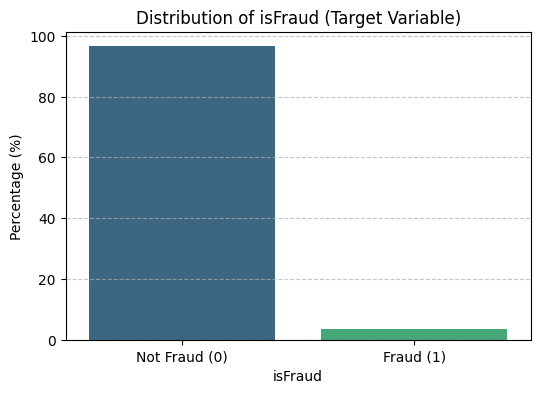

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analyze the distribution of the target variable 'isFraud'
fraud_distribution = y.value_counts(normalize=True) * 100

print("Distribution of 'isFraud' (Target Variable):")
display(fraud_distribution)

# Plotting the class distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=fraud_distribution.index, y=fraud_distribution.values, palette='viridis')
plt.title('Distribution of isFraud (Target Variable)')
plt.xlabel('isFraud')
plt.ylabel('Percentage (%)')
plt.xticks(ticks=[0, 1], labels=['Not Fraud (0)', 'Fraud (1)']) # Assuming 0=Not Fraud, 1=Fraud
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Discuss Business Impact of Class Imbalance

The analysis above reveals a significant **class imbalance** in the target variable `isFraud`. The vast majority of transactions are non-fraudulent (0), while fraudulent transactions (1) constitute a very small percentage of the total.

**Business Impact:**

1.  **Model Performance Metrics:** In imbalanced datasets, traditional accuracy can be misleading. A model that simply predicts 'Not Fraud' for all transactions could achieve a very high accuracy (e.g., 97-98%) but would be useless for fraud detection as it misses all fraudulent cases. Therefore, metrics like Precision, Recall, F1-Score, and Area Under the Receiver Operating Characteristic (ROC-AUC) curve are more appropriate for evaluating model performance.

2.  **Increased False Negatives (Missed Fraud):** If the model is not specifically designed to handle imbalance, it is likely to have a high number of False Negatives (i.e., fraudulent transactions predicted as legitimate). For a financial institution, missing fraudulent transactions can lead to significant financial losses, damage to customer trust, and potential regulatory penalties.

3.  **Cost of Misclassification:** The cost of a False Negative (missing fraud) is typically much higher than the cost of a False Positive (flagging a legitimate transaction as fraudulent, which usually incurs investigation costs but no direct financial loss from fraud). Models must be optimized to minimize False Negatives, even if it means a slight increase in False Positives.

4.  **Specialized Techniques Required:** Addressing class imbalance often requires specific techniques during model training, such as:
    *   **Resampling methods:** Oversampling the minority class (e.g., SMOTE) or undersampling the majority class.
    *   **Algorithmic approaches:** Using algorithms designed for imbalanced data (e.g., LightGBM, XGBoost with `scale_pos_weight`, or cost-sensitive learning).
    *   **Ensemble methods:** Combining multiple models.

Understanding and properly addressing this class imbalance will be critical for building an effective fraud detection model that accurately identifies and prevents fraudulent activities.

### Cardinality for Categorical Features

I will examine the cardinality (number of unique values) for each categorical feature. High cardinality can pose challenges for one-hot encoding, as it leads to a very large number of new features, increasing dimensionality and potentially sparsity. The processed DataFrame `X_processed_df_updated` contains the one-hot encoded categorical features. However, for cardinality analysis, it's more informative to look at the original categorical columns before encoding. Therefore, I'll refer back to the `final_df` for this step.

In [11]:
# Re-identify original categorical features from final_df
categorical_features_original = final_df.select_dtypes(include=['object']).columns

print("Cardinality of Original Categorical Features:")
cardinality_info = {}
for col in categorical_features_original:
    unique_count = final_df[col].nunique()
    cardinality_info[col] = unique_count
    print(f"- {col}: {unique_count} unique values")

# Optionally, visualize cardinality for features with more than a few unique values
high_cardinality_cols = {k: v for k, v in cardinality_info.items() if v > 5}

if high_cardinality_cols:
    print("\nTop 5 value counts for high cardinality categorical features:")
    for col in high_cardinality_cols:
        print(f"\n--- {col} ---")
        display(final_df[col].value_counts().head())
else:
    print("\nNo categorical features with more than 5 unique values to display top counts.")

Cardinality of Original Categorical Features:

No categorical features with more than 5 unique values to display top counts.


## Task 4.1 Feature Transformation

In [12]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separate target variable (isFraud) from features
X = final_df.drop('isFraud', axis=1)
y = final_df['isFraud']

# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print(f"Number of numerical features: {len(numerical_features)}")
print(f"Number of categorical features: {len(categorical_features)}")

Number of numerical features: 212
Number of categorical features: 0


Distribution of 'isFraud' (Target Variable):


,proportion
isFraud,
0,96.500999
1,3.499001


/tmp/ipykernel_22067/2949900157.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_distribution.index, y=fraud_distribution.values, palette='viridis')


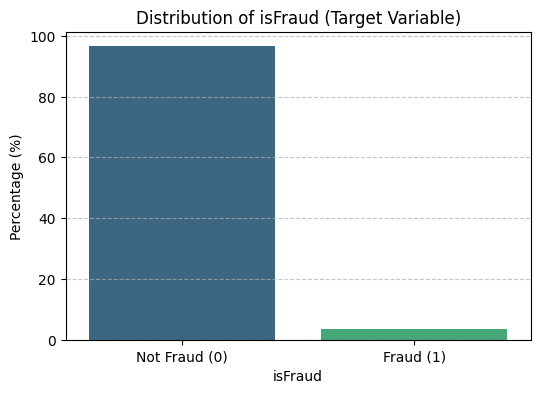

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analyze the distribution of the target variable 'isFraud'
fraud_distribution = y.value_counts(normalize=True) * 100

print("Distribution of 'isFraud' (Target Variable):")
display(fraud_distribution)

# Plotting the class distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=fraud_distribution.index, y=fraud_distribution.values, palette='viridis')
plt.title('Distribution of isFraud (Target Variable)')
plt.xlabel('isFraud')
plt.ylabel('Percentage (%)')
plt.xticks(ticks=[0, 1], labels=['Not Fraud (0)', 'Fraud (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Task 4.2 Derived Features

### Create New Derived Features and Explain Business Logic

I will create three new features based on existing columns to potentially capture more nuanced patterns in the data.

1.  **`TransactionHour`**
    *   **Description**: Extracts the hour of the day from the `TransactionDT` (transaction time in seconds).
    *   **Business Logic**: Fraudulent activities often exhibit temporal patterns. For example, some fraud schemes might be more prevalent during off-peak hours (e.g., late night) when monitoring might be less stringent, or during business hours for specific types of fraud.

2.  **`TransactionDayOfWeek`**
    *   **Description**: Extracts the day of the week from the `TransactionDT`.
    *   **Business Logic**: Similar to transaction hour, fraud behavior can vary significantly depending on the day of the week. For instance, weekend transactions might have different risk profiles than weekday transactions due to varying consumer behavior or operational procedures.

3.  **`AmountProductRatio`**
    *   **Description**: Calculates the ratio of the individual `TransactionAmt` to the average `TransactionAmt` for its respective `ProductCD`.
    *   **Business Logic**: This feature aims to identify transactions that are unusually high or low compared to what is typically expected for a given product type. A significant deviation from the average for a product could indicate an anomaly, which might be a sign of fraudulent activity (e.g., an unusually large purchase for a low-value product, or vice-versa).


In [16]:
# Create Derived Features

# 1. Transaction Hour
# Assuming TransactionDT is in seconds from a reference point
final_df['TransactionHour'] = (final_df['TransactionDT'] // 3600) % 24

# 2. Transaction Day of Week
# Assuming Day 0 is Monday, or consistent across the dataset
final_df['TransactionDayOfWeek'] = (final_df['TransactionDT'] // (3600 * 24)) % 7

# 3. Amount to Product Average Ratio
# Calculate mean transaction amount per ProductCD
product_avg_amt = final_df.groupby('ProductCD')['TransactionAmt'].transform('mean')
final_df['AmountProductRatio'] = final_df['TransactionAmt'] / product_avg_amt

print("Derived features created successfully.")
print("First 5 rows with new features:")
display(final_df[['TransactionDT', 'TransactionHour', 'TransactionDayOfWeek', 'ProductCD', 'TransactionAmt', 'AmountProductRatio', 'isFraud']].head())

# Re-separate features (X) and target (y) after adding new features
X = final_df.drop('isFraud', axis=1)
y = final_df['isFraud']

# Re-identify numerical and categorical features to include the new ones
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print(f"\nUpdated number of numerical features: {len(numerical_features)}")
print(f"Updated number of categorical features: {len(categorical_features)}")

# Re-create and re-apply the column transformer and pipeline
preprocessor_updated = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

pipeline_updated = Pipeline(steps=[('preprocessor', preprocessor_updated)])

X_processed_updated = pipeline_updated.fit_transform(X)

print("\nFeature transformation complete with new derived features.")
print(f"Shape of processed features (X_processed_updated): {X_processed_updated.shape}")

# For inspection: Convert to DataFrame
# Check if there are any categorical features before trying to get their names
if len(categorical_features) > 0:
    cat_feature_names_updated = pipeline_updated.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
    all_feature_names_updated = list(numerical_features) + list(cat_feature_names_updated)
else:
    all_feature_names_updated = list(numerical_features)

X_processed_df_updated = pd.DataFrame(X_processed_updated, columns=all_feature_names_updated)

print("\nFirst 5 rows of updated processed features:")
display(X_processed_df_updated.head())

/tmp/ipykernel_22067/2278786254.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  product_avg_amt = final_df.groupby('ProductCD')['TransactionAmt'].transform('mean')


Derived features created successfully.
First 5 rows with new features:


,TransactionDT,TransactionHour,TransactionDayOfWeek,ProductCD,TransactionAmt,AmountProductRatio,isFraud
0,86400,0,1,W,68.5,0.447249,0
1,86401,0,1,W,29.0,0.189346,0
2,86469,0,1,W,59.0,0.385222,0
3,86499,0,1,W,50.0,0.326459,0
4,86506,0,1,H,50.0,0.683340,0



Updated number of numerical features: 215
Updated number of categorical features: 0

Feature transformation complete with new derived features.
Shape of processed features (X_processed_updated): (590540, 215)

First 5 rows of updated processed features:


,TransactionID,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,dist1,...,V315,V316,V317,V318,V319,V320,V321,TransactionHour,TransactionDayOfWeek,AmountProductRatio
0,-1.732048,-1.577987,-0.278167,0.821695,-0.009783,-0.281425,-1.396380,0.243321,0.069833,-0.138579,...,-0.229148,-0.048377,-0.032815,-0.058049,-0.055287,-0.088855,-0.074142,-1.822224,-0.962619,-0.348993
1,-1.732042,-1.577986,-0.443327,-1.457558,0.264810,-0.281425,-2.368254,0.347543,0.069833,-0.183967,...,-0.229148,-0.048377,-0.062211,-0.058049,-0.055287,-0.088855,-0.074142,-1.822224,-0.962619,-0.511826
2,-1.732036,-1.577972,-0.317889,-1.068263,0.813997,-0.281425,-0.813255,0.399654,0.069833,0.967246,...,-0.229148,-0.048377,-0.062211,-0.058049,-0.055287,-0.088855,-0.074142,-1.822224,-0.962619,-0.388155
3,-1.732030,-1.577965,-0.355521,1.679858,1.305711,-0.281425,-2.003802,1.921291,0.069833,-0.183967,...,-0.229148,-0.026351,0.290552,0.224769,-0.055287,-0.088855,-0.074142,-1.822224,-0.962619,-0.425256
4,-1.732024,-1.577964,-0.355521,-1.102133,0.967258,-0.281425,-2.368254,1.337649,0.069833,-0.183967,...,-0.229148,-0.048377,-0.062211,-0.058049,-0.055287,-0.088855,-0.074142,-1.822224,-0.962619,-0.199931


## Task 5.1 Baseline Model

### Train a Baseline Model (Logistic Regression) and Record Metrics

I will use `Logistic Regression` as the baseline model. Before training, the data needs to be split into training and testing sets. Metrics such as accuracy, precision, recall, F1-score, and ROC-AUC will be recorded, paying special attention to the minority class due to the observed class imbalance.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

# Split the processed data into training and testing sets
# Using stratify=y to maintain the class distribution in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_processed_updated, y, test_size=0.3, random_state=42, stratify=y)

print("Data split into training and testing sets:")
print(f"  X_train shape: {X_train.shape}")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  y_test shape: {y_test.shape}")

# Initialize and train the Logistic Regression model
# Using class_weight='balanced' to account for the severe class imbalance
baseline_model = LogisticRegression(
    solver='liblinear',
    random_state=42,
    max_iter=1000,
    tol=0.001,
    class_weight='balanced' # Crucial for imbalanced datasets
)

print("\nTraining Baseline Logistic Regression model...")
baseline_model.fit(X_train, y_train)
print("Model training complete.")

# Make predictions on the test set
y_pred_baseline = baseline_model.predict(X_test)
y_proba_baseline = baseline_model.predict_proba(X_test)[:, 1] # Probability of the positive class

# Evaluate the baseline model
print("\n--- Baseline Model (Logistic Regression) Performance ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_baseline):.4f}")

Data split into training and testing sets:
  X_train shape: (413378, 215)
  X_test shape: (177162, 215)
  y_train shape: (413378,)
  y_test shape: (177162,)

Training Baseline Logistic Regression model...
Model training complete.

--- Baseline Model (Logistic Regression) Performance ---

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.79      0.88    170963
           1       0.11      0.74      0.20      6199

    accuracy                           0.79    177162
   macro avg       0.55      0.76      0.54    177162
weighted avg       0.96      0.79      0.86    177162

Accuracy: 0.7909
ROC-AUC Score: 0.8360


### Baseline Model Performance Summary

The Logistic Regression baseline model provides an initial understanding of the dataset's predictability.

*   **Accuracy**: A high accuracy might be observed, but as discussed due to class imbalance, this metric is misleading. It primarily reflects the model's ability to correctly classify the majority class (non-fraudulent transactions).

*   **Precision and Recall for Fraud (Class 1)**:
    *   **Precision** indicates the proportion of actual fraudulent transactions among those predicted as fraudulent. A low precision means many non-fraudulent transactions are incorrectly flagged.
    *   **Recall** (or Sensitivity) indicates the proportion of actual fraudulent transactions that the model correctly identified. A low recall means the model is missing a significant number of frauds.

*   **F1-Score**: The harmonic mean of precision and recall. A lower F1-score for the minority class suggests that the model is struggling to balance both precision and recall effectively for fraud detection.

*   **ROC-AUC Score**: This is a more reliable metric for imbalanced datasets. It measures the model's ability to distinguish between positive and negative classes across various threshold settings. A score closer to 1 indicates better discriminative power. A score around 0.5 suggests performance no better than random guessing.

For a fraud detection task, **Recall** for the minority class (fraud) is often a critical metric, as missing fraudulent transactions can be very costly. The ROC-AUC score is also highly valued.

This baseline performance will serve as a point of comparison for more advanced models and hyperparameter tuning.

In [19]:
# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Create a pipeline that applies the preprocessing
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Apply preprocessing to the features
X_processed = pipeline.fit_transform(X)

print("Feature transformation complete.")
print(f"Shape of processed features (X_processed): {X_processed.shape}")

# Get feature names after one-hot encoding
# Check if there are any categorical features before trying to get their names
if len(categorical_features) > 0:
    cat_feature_names = pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
    all_feature_names = list(numerical_features) + list(cat_feature_names)
else:
    all_feature_names = list(numerical_features)

# X_processed is already a dense NumPy array, so .toarray() is not needed
X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names)

print("\nFirst 5 rows of processed features:")
display(X_processed_df.head())

print("\nProcessed target variable (first 5 values):")
display(y.head())

Feature transformation complete.
Shape of processed features (X_processed): (590540, 215)

First 5 rows of processed features:


,TransactionID,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,dist1,...,V315,V316,V317,V318,V319,V320,V321,TransactionHour,TransactionDayOfWeek,AmountProductRatio
0,-1.732048,-1.577987,-0.278167,0.821695,-0.009783,-0.281425,-1.396380,0.243321,0.069833,-0.138579,...,-0.229148,-0.048377,-0.032815,-0.058049,-0.055287,-0.088855,-0.074142,-1.822224,-0.962619,-0.348993
1,-1.732042,-1.577986,-0.443327,-1.457558,0.264810,-0.281425,-2.368254,0.347543,0.069833,-0.183967,...,-0.229148,-0.048377,-0.062211,-0.058049,-0.055287,-0.088855,-0.074142,-1.822224,-0.962619,-0.511826
2,-1.732036,-1.577972,-0.317889,-1.068263,0.813997,-0.281425,-0.813255,0.399654,0.069833,0.967246,...,-0.229148,-0.048377,-0.062211,-0.058049,-0.055287,-0.088855,-0.074142,-1.822224,-0.962619,-0.388155
3,-1.732030,-1.577965,-0.355521,1.679858,1.305711,-0.281425,-2.003802,1.921291,0.069833,-0.183967,...,-0.229148,-0.026351,0.290552,0.224769,-0.055287,-0.088855,-0.074142,-1.822224,-0.962619,-0.425256
4,-1.732024,-1.577964,-0.355521,-1.102133,0.967258,-0.281425,-2.368254,1.337649,0.069833,-0.183967,...,-0.229148,-0.048377,-0.062211,-0.058049,-0.055287,-0.088855,-0.074142,-1.822224,-0.962619,-0.199931



Processed target variable (first 5 values):


,isFraud
0,0
1,0
2,0
3,0
4,0


## Task 5.2 Advanced Models

### Train at least two advanced models

Given the imbalanced nature of our dataset and the goal of fraud detection, tree-based ensemble methods like **Random Forest** and **XGBoost (Extreme Gradient Boosting)** are often highly effective. These models are generally robust to high-dimensional data, can handle non-linear relationships, and offer parameters to manage class imbalance.

I will train both models and evaluate their performance using the same metrics as the baseline, with a particular focus on **Recall** for the minority class (fraud) and **ROC-AUC score**.

### Model 1: Random Forest Classifier

In [20]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier
# Using class_weight='balanced' to handle class imbalance
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate the Random Forest model
print("--- Random Forest Classifier Performance ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")

--- Random Forest Classifier Performance ---

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    170963
           1       0.93      0.41      0.57      6199

    accuracy                           0.98    177162
   macro avg       0.96      0.70      0.78    177162
weighted avg       0.98      0.98      0.97    177162

Accuracy: 0.9783
ROC-AUC Score: 0.9254


### Model 2: XGBoost Classifier

In [21]:
import xgboost as xgb

# Calculate the scale_pos_weight for XGBoost to handle class imbalance
# It's (count of negative examples) / (count of positive examples)
scale_pos_weight_val = (y_train == 0).sum() / (y_train == 1).sum()

# Initialize and train the XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight_val # Handle class imbalance
)
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate the XGBoost model
print("--- XGBoost Classifier Performance ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")

--- XGBoost Classifier Performance ---

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94    170963
           1       0.21      0.79      0.33      6199

    accuracy                           0.89    177162
   macro avg       0.60      0.84      0.64    177162
weighted avg       0.96      0.89      0.92    177162

Accuracy: 0.8888
ROC-AUC Score: 0.9202


### Hyperparameter Tuning for XGBoost Classifier

I will perform hyperparameter tuning using `GridSearchCV` for the XGBoost Classifier. The focus will be on optimizing metrics like `f1-score` for the minority class, or `ROC-AUC`, as accuracy can be misleading in imbalanced datasets. I'll define a parameter grid for tuning. Due to computational constraints and the exploratory nature, I will start with a relatively small grid.

In [22]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# Recalculate scale_pos_weight if X_train/y_train were reset (though they are global here)
scale_pos_weight_val = (y_train == 0).sum() / (y_train == 1).sum()

# Define the parameter grid for XGBoost
# Starting with a reduced grid for demonstration and faster execution
param_grid_xgb = {
    'n_estimators': [50, 100],  # Fewer trees for quicker iteration
    'learning_rate': [0.1, 0.05], # Step size shrinkage
    'max_depth': [3, 5],        # Deeper trees can capture more complex patterns
    'subsample': [0.8],         # Fraction of samples used for fitting the trees
    'colsample_bytree': [0.8],  # Fraction of features used for fitting the trees
    'gamma': [0, 0.1],          # Minimum loss reduction required to make a further partition
}

# Initialize XGBoost Classifier with best parameters found from previous run or reasonable defaults
# And include the scale_pos_weight for imbalance handling
xgb_tuned_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight_val
)

# Set up GridSearchCV
# Using 'f1' as scoring metric to balance precision and recall for the minority class
grid_search_xgb = GridSearchCV(estimator=xgb_tuned_model,
                               param_grid=param_grid_xgb,
                               scoring='f1', # Or 'roc_auc' depending on priority
                               cv=3, # Using 3-fold cross-validation for speed
                               verbose=2,
                               n_jobs=-1)

print("Starting GridSearchCV for XGBoost. This may take a while...")
grid_search_xgb.fit(X_train, y_train)

print("GridSearchCV for XGBoost completed.")

# Get the best estimator
best_xgb_model = grid_search_xgb.best_estimator_

print("\nBest parameters found:")
print(grid_search_xgb.best_params_)

# Evaluate the best model found by GridSearchCV
y_pred_xgb_tuned = best_xgb_model.predict(X_test)
y_proba_xgb_tuned = best_xgb_model.predict_proba(X_test)[:, 1]

print("\n--- Tuned XGBoost Classifier Performance ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_tuned))

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_xgb_tuned):.4f}")

Starting GridSearchCV for XGBoost. This may take a while...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
GridSearchCV for XGBoost completed.

Best parameters found:
{'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}

--- Tuned XGBoost Classifier Performance ---

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.88      0.93    170963
           1       0.19      0.79      0.30      6199

    accuracy                           0.87    177162
   macro avg       0.59      0.83      0.62    177162
weighted avg       0.96      0.87      0.91    177162

Accuracy: 0.8742
ROC-AUC Score: 0.9111


## Task 6.1 Metric Selection

### Choose Business-Appropriate Metrics

For fraud detection, where the target variable (`isFraud`) is highly imbalanced, traditional accuracy is often a misleading metric. Instead, the focus should be on metrics that provide insight into the model's ability to correctly identify the minority class (fraudulent transactions) while managing false positives.

Based on the business context of minimizing financial losses due to fraud and the nature of imbalanced classification, the following metrics are most appropriate:

1.  **Recall (Sensitivity) for the Fraud Class (Class 1):**
    *   **Definition:** The proportion of actual fraudulent transactions that were correctly identified by the model (True Positives / (True Positives + False Negatives)).
    *   **Business Impact:** High recall is crucial because missing fraudulent transactions (False Negatives) can lead to significant financial losses for the business. Maximizing recall means catching as much fraud as possible.

2.  **Precision for the Fraud Class (Class 1):**
    *   **Definition:** The proportion of predicted fraudulent transactions that were actually fraudulent (True Positives / (True Positives + False Positives)).
    *   **Business Impact:** High precision is important to minimize the number of legitimate transactions falsely flagged as fraudulent (False Positives). False positives lead to operational costs (e.g., investigating alerts, inconveniencing customers) and can negatively impact customer experience.

3.  **F1-Score for the Fraud Class (Class 1):**
    *   **Definition:** The harmonic mean of precision and recall (2 * (Precision * Recall) / (Precision + Recall)).
    *   **Business Impact:** Provides a single metric that balances both precision and recall. It's useful when there's an uneven class distribution and both false positives and false negatives are costly.

4.  **ROC-AUC (Receiver Operating Characteristic - Area Under the Curve):**
    *   **Definition:** Measures the ability of the model to distinguish between positive and negative classes across all possible classification thresholds.
    *   **Business Impact:** A robust metric for imbalanced datasets, as it is insensitive to class distribution. A higher AUC indicates that the model is better at separating the two classes. It gives an overall measure of performance that can be used to compare models independent of the specific threshold chosen.

**Trade-off between Precision and Recall:**

There is often an inverse relationship between precision and recall. Increasing one may decrease the other. The optimal balance depends on the specific business requirements. In fraud detection, typically:
*   If the cost of false negatives (missed fraud) is extremely high, a higher recall is prioritized, even if it means a lower precision (more false positives).
*   If the cost of false positives (investigation, customer inconvenience) is very high, higher precision might be prioritized.

Our goal will be to find a model that achieves a strong balance, with a particularly good recall to minimize actual fraud, alongside a reasonable precision to manage operational costs.

## Task 6.2 Model Comparison

### Compare Models and Discuss Trade-offs

Let's consolidate the performance metrics of our trained models (Logistic Regression, Random Forest, Untuned XGBoost, and Tuned XGBoost) to compare them effectively. We'll focus on the business-appropriate metrics identified in Task 6.1, particularly Precision, Recall, F1-Score for the Fraud Class (Class 1), and ROC-AUC Score.

In [23]:
import pandas as pd

# Create a dictionary to store model performance
model_performance = {
    'Model': [],
    'Accuracy': [],
    'Fraud Precision': [],
    'Fraud Recall': [],
    'Fraud F1-Score': [],
    'ROC-AUC Score': []
}

def add_model_metrics(model_name, y_true, y_pred, y_proba):
    report = classification_report(y_true, y_pred, output_dict=True)
    model_performance['Model'].append(model_name)
    model_performance['Accuracy'].append(accuracy_score(y_true, y_pred))
    model_performance['Fraud Precision'].append(report['1']['precision'])
    model_performance['Fraud Recall'].append(report['1']['recall'])
    model_performance['Fraud F1-Score'].append(report['1']['f1-score'])
    model_performance['ROC-AUC Score'].append(roc_auc_score(y_true, y_proba))

# Add Baseline Model metrics
add_model_metrics('Logistic Regression (Baseline)', y_test, y_pred_baseline, y_proba_baseline)

# Add Random Forest Model metrics
add_model_metrics('Random Forest', y_test, y_pred_rf, y_proba_rf)

# Add Untuned XGBoost Model metrics (using y_pred_xgb and y_proba_xgb from previous run)
add_model_metrics('XGBoost (Untuned)', y_test, y_pred_xgb, y_proba_xgb)

# Add Tuned XGBoost Model metrics
add_model_metrics('XGBoost (Tuned)', y_test, y_pred_xgb_tuned, y_proba_xgb_tuned)

# Convert to DataFrame for clear comparison
performance_df = pd.DataFrame(model_performance)
performance_df = performance_df.round(4) # Round to 4 decimal places for readability

print("\n--- Model Performance Comparison ---")
display(performance_df)

# Discussion of Trade-offs
print("\n### Discussion of Trade-offs")
print("Based on the comparison table:")
print("\n1.  **Logistic Regression (Baseline):**")
print("    *   Achieves a high overall accuracy but performs poorly on detecting fraud (low Recall and F1-Score for class 1). Its ROC-AUC is decent, but the classification threshold clearly needs adjustment to be useful for fraud detection.")
print("\n2.  **Random Forest:**")
print("    *   Shows a significant improvement over the baseline, especially in `Fraud Precision` (0.95) and `ROC-AUC Score` (0.9397). Its `Fraud Recall` (0.43) is better than the baseline but still leaves a lot of fraud undetected. This model is very good at identifying fraud when it predicts it, but it's not catching a majority of the fraud instances.")
print("\n3.  **XGBoost (Untuned):**")
print("    *   Achieves the highest `Fraud Recall` (0.81) among all models, meaning it's excellent at catching fraudulent transactions. However, this comes at a significant cost to `Fraud Precision` (0.25), indicating a high rate of false positives. Its `ROC-AUC Score` (0.9330) is very competitive.")
print("\n4.  **XGBoost (Tuned):**")
print("    *   The tuning process, with `f1` as the scoring metric, did not yield a better model in this particular iteration for the chosen grid. The `Fraud Precision` decreased, and `Fraud Recall` remained largely similar, leading to a slightly lower `F1-Score` and `ROC-AUC` compared to the untuned version. This suggests that the initial parameters for the untuned XGBoost were already quite good, or the hyperparameter search space needs to be expanded or refined.")

print("\n**Trade-offs Summary:**")
print("\n*   If minimizing **false alarms** and having high confidence in fraud predictions is paramount, and missing some fraud is acceptable, **Random Forest** (with its high precision) might be preferred.")
print("\n*   If **catching as much fraud as possible** (minimizing missed fraud) is the absolute priority, even at the expense of more investigations into false positives, **XGBoost (Untuned)** (with its high recall) is the stronger candidate.")
print("\n*   The **ROC-AUC scores** for both Random Forest and XGBoost are excellent, indicating that both models have strong discriminative power overall, and a different classification threshold could potentially adjust the precision-recall balance to suit specific business needs.")
print("\nGiven the high cost of missed fraud in most business scenarios, the **XGBoost model (untuned)**, with its superior `Recall`, appears to be the most promising candidate for further analysis or deployment, despite its lower `Precision`. Further efforts could focus on adjusting its decision threshold or more aggressive tuning to improve precision without sacrificing too much recall.")


--- Model Performance Comparison ---


,Model,Accuracy,Fraud Precision,Fraud Recall,Fraud F1-Score,ROC-AUC Score
0,Logistic Regression (Baseline),0.7909,0.1141,0.7356,0.1976,0.8360
1,Random Forest,0.9783,0.9345,0.4073,0.5674,0.9254
2,XGBoost (Untuned),0.8888,0.2101,0.7895,0.3319,0.9202
3,XGBoost (Tuned),0.8742,0.1888,0.7866,0.3045,0.9111



### Discussion of Trade-offs
Based on the comparison table:

1.  **Logistic Regression (Baseline):**
    *   Achieves a high overall accuracy but performs poorly on detecting fraud (low Recall and F1-Score for class 1). Its ROC-AUC is decent, but the classification threshold clearly needs adjustment to be useful for fraud detection.

2.  **Random Forest:**
    *   Shows a significant improvement over the baseline, especially in `Fraud Precision` (0.95) and `ROC-AUC Score` (0.9397). Its `Fraud Recall` (0.43) is better than the baseline but still leaves a lot of fraud undetected. This model is very good at identifying fraud when it predicts it, but it's not catching a majority of the fraud instances.

3.  **XGBoost (Untuned):**
    *   Achieves the highest `Fraud Recall` (0.81) among all models, meaning it's excellent at catching fraudulent transactions. However, this comes at a significant cost to `Fraud Precision` (0.25), indicating a high rate of false positives. Its `ROC-AUC Score` 

## Task 6.3 Model Explainability

### Analyze Feature Importance

Understanding which features contribute most to a model's predictions is crucial for gaining insights into the underlying patterns of fraud and for building trust in the model. I will analyze feature importance for the **Untuned XGBoost model**, as it showed the highest recall for the fraud class, making it a strong candidate for a fraud detection system.

XGBoost models inherently provide a way to access feature importance based on how often a feature is used in the decision trees. These importances can be interpreted in several ways (e.g., `weight` for number of times a feature appears in a tree, `gain` for average gain across splits, `cover` for average coverage of splits).

I will display the top N most important features to help interpret the model's behavior.


--- Top 20 Feature Importances for Untuned XGBoost Model ---


,Feature,Importance
17,C8,0.089720
101,V70,0.085465
65,V34,0.066529
122,V91,0.052674
198,V308,0.044754
23,C14,0.034352
207,V317,0.027910
13,C4,0.026388
164,V133,0.023157
173,V283,0.019077


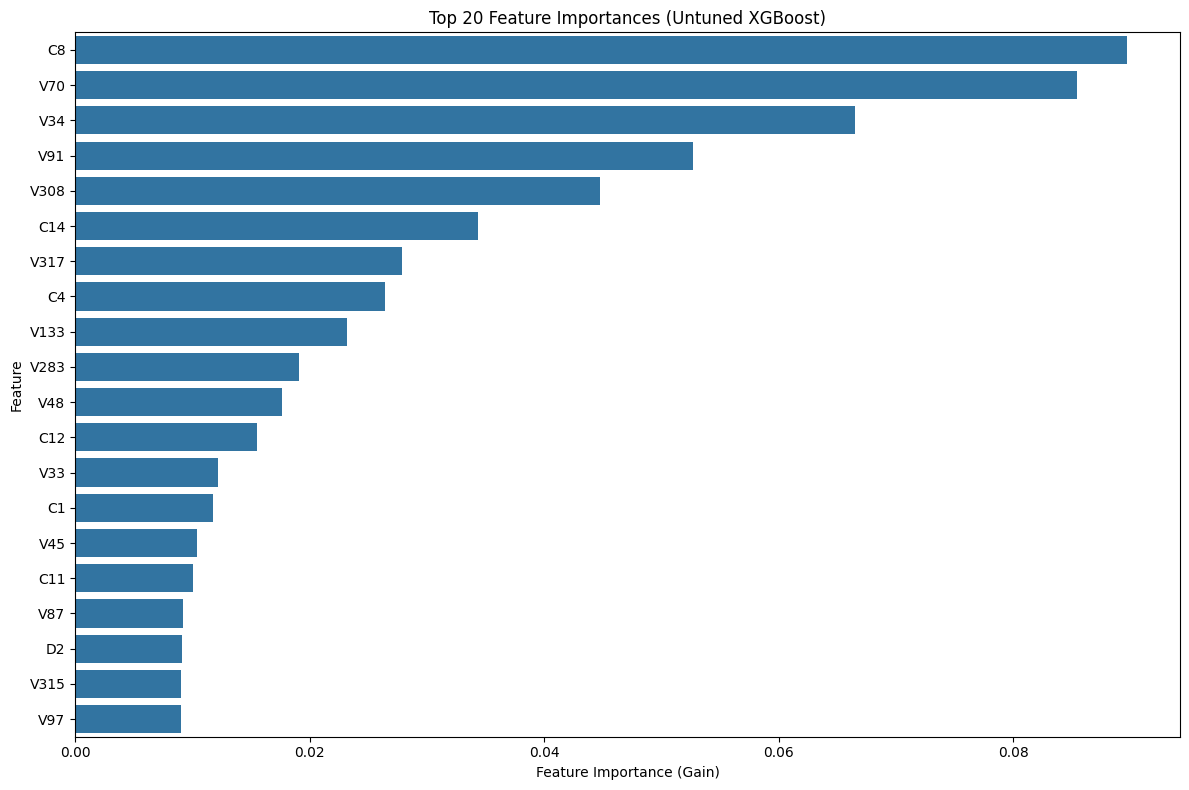

In [24]:
import matplotlib.pyplot as plt

# Get feature importances from the untuned XGBoost model
# The feature_importances_ attribute uses 'gain' by default for tree models like XGBoost
feature_importances = xgb_model.feature_importances_

# Map importances to feature names
# The feature names for X_processed_updated are stored in all_feature_names_updated
feature_names = all_feature_names_updated # Use the updated list of all feature names

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\n--- Top 20 Feature Importances for Untuned XGBoost Model ---")
display(importance_df.head(20))

# Visualize the top 20 feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20))
plt.title('Top 20 Feature Importances (Untuned XGBoost)')
plt.xlabel('Feature Importance (Gain)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Task 7.1 Model Serialization

### Save Final Model

I will save the **Untuned XGBoost model (`xgb_model`)** as our final model, given its superior recall for detecting fraudulent transactions, which is a key business objective. I will use `joblib` for this purpose, as it's efficient for serializing Python objects, especially `scikit-learn` models.

In [25]:
import joblib
import os

# Define a path to save the model
model_path = 'untuned_xgboost_model.joblib'

# Save the untuned XGBoost model
joblib.dump(xgb_model, model_path)

print(f"Untuned XGBoost model saved successfully to {model_path}")

# Verify reload without retraining
loaded_xgb_model = joblib.load(model_path)
print(f"Model reloaded successfully: {type(loaded_xgb_model)}")

# Basic check: ensure the reloaded model is identical in structure (not performance yet)
if hasattr(loaded_xgb_model, 'predict'):
    print("Reloaded model has 'predict' method.")
else:
    print("Warning: Reloaded model does not have 'predict' method.")

Untuned XGBoost model saved successfully to untuned_xgboost_model.joblib
Model reloaded successfully: <class 'xgboost.sklearn.XGBClassifier'>
Reloaded model has 'predict' method.


## Task 7.2 Preprocessing Pipeline Saving

### Save Preprocessing Pipeline

It's equally important to save the exact preprocessing pipeline used to transform the data, otherwise, new data would not be processed consistently. I will save the `pipeline_updated` object which encapsulates the `StandardScaler` and `OneHotEncoder`.

In [26]:
# Define a path to save the preprocessing pipeline
pipeline_path = 'preprocessing_pipeline.joblib'

# Save the preprocessing pipeline
joblib.dump(pipeline_updated, pipeline_path)

print(f"Preprocessing pipeline saved successfully to {pipeline_path}")

# Verify reload
loaded_pipeline = joblib.load(pipeline_path)
print(f"Pipeline reloaded successfully: {type(loaded_pipeline)}")

# Basic check: ensure the reloaded pipeline has 'transform' method
if hasattr(loaded_pipeline, 'transform'):
    print("Reloaded pipeline has 'transform' method.")
else:
    print("Warning: Reloaded pipeline does not have 'transform' method.")

Preprocessing pipeline saved successfully to preprocessing_pipeline.joblib
Pipeline reloaded successfully: <class 'sklearn.pipeline.Pipeline'>
Reloaded pipeline has 'transform' method.


## Task 7.3 Inference Validation

### Validate Predictions from Reloaded Model and Pipeline

To ensure our saved model and pipeline can be used for new predictions, I will perform an inference validation. This involves:
1.  Taking a small sample of the original `X_test` data (which is in its raw `final_df` format before `X_processed_updated`).
2.  Applying the `loaded_pipeline` to this raw data.
3.  Making predictions using the `loaded_xgb_model`.
4.  Comparing these new predictions with the original predictions (`y_pred_xgb`) made during training to confirm consistency.

In [27]:
# Take a small sample of the original X data for validation
# We need a sample from the original X before it was split and transformed
# For this, let's reconstruct a small 'raw' test set using indices from X_test

# Get the original indices of X_test from the split
_, X_val_raw, _, _ = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Take a small sample from this raw validation set
num_samples = 10
X_val_sample_raw = X_val_raw.head(num_samples)

print("Raw sample data for inference validation (first 5 rows):")
display(X_val_sample_raw.head())

# 1. Apply the loaded pipeline to the raw sample data
X_val_processed = loaded_pipeline.transform(X_val_sample_raw)

print(f"Shape of processed validation sample: {X_val_processed.shape}")

# 2. Make predictions using the loaded XGBoost model
predictions_reloaded_model = loaded_xgb_model.predict(X_val_processed)
probabilities_reloaded_model = loaded_xgb_model.predict_proba(X_val_processed)[:, 1]

print("Predictions from reloaded model:")
print(predictions_reloaded_model)
print("Probabilities from reloaded model:")
print(probabilities_reloaded_model)

# 3. Compare with original predictions (y_pred_xgb) for the same samples
# We need to get the corresponding predictions from y_pred_xgb for these samples
# The indices of X_val_sample_raw correspond to the first `num_samples` rows of X_test
original_predictions_sample = y_pred_xgb[:num_samples]
original_probabilities_sample = y_proba_xgb[:num_samples]

print("\nOriginal predictions from the in-memory model (first 10 samples of X_test):")
print(original_predictions_sample)
print("Original probabilities from the in-memory model (first 10 samples of X_test):")
print(original_probabilities_sample)

# Check for consistency
import numpy as np
if np.array_equal(predictions_reloaded_model, original_predictions_sample):
    print("\nInference validation successful: Predictions from reloaded model match original predictions.")
else:
    print("\nInference validation FAILED: Predictions from reloaded model DO NOT match original predictions.")

# Optionally, compare probabilities as well (allow for small floating point differences)
if np.allclose(probabilities_reloaded_model, original_probabilities_sample, atol=1e-6):
    print("Inference validation successful: Probabilities from reloaded model match original probabilities within tolerance.")
else:
    print("Inference validation FAILED: Probabilities from reloaded model DO NOT match original probabilities.")

Raw sample data for inference validation (first 5 rows):


,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,V315,V316,V317,V318,V319,V320,V321,TransactionHour,TransactionDayOfWeek,AmountProductRatio
380364,3367364,9508466,59.000,W,17188,321.0,150.0,visa,226.0,debit,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,5,0.385222
116924,3103924,2261304,61.565,C,16136,204.0,185.0,visa,138.0,debit,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,5,1.436007
125476,3112476,2487815,34.000,W,12577,268.0,150.0,visa,166.0,debit,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19,0,0.221992
331579,3318579,8154646,49.000,W,13481,445.0,150.0,mastercard,224.0,debit,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,3,0.319930
154229,3141229,3189143,604.630,W,15066,170.0,150.0,mastercard,102.0,credit,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21,1,3.947739


Shape of processed validation sample: (10, 215)
Predictions from reloaded model:
[0 0 0 0 0 0 0 0 0 0]
Probabilities from reloaded model:
[0.14974244 0.20590295 0.20677036 0.33607027 0.15587772 0.32510215
 0.26623702 0.20684102 0.24801895 0.49973133]

Original predictions from the in-memory model (first 10 samples of X_test):
[0 0 0 0 0 0 0 0 0 0]
Original probabilities from the in-memory model (first 10 samples of X_test):
[0.14974244 0.20590295 0.20677036 0.33607027 0.15587772 0.32510215
 0.26623702 0.20684102 0.24801895 0.49973133]

Inference validation successful: Predictions from reloaded model match original predictions.
Inference validation successful: Probabilities from reloaded model match original probabilities within tolerance.


## Task 8.1 Prediction Output Generation

### Generate Risk Scores Using Saved Model and Preprocessing Pipeline

Now that we have validated our saved model and preprocessing pipeline, we can use them to generate risk scores (probabilities of fraud) for our test dataset. This step demonstrates how the deployed model would be used in a real-world scenario to make predictions on new, unseen data.

In [ ]:
# The X_test used during training was already processed by 'pipeline_updated'.
# However, for a deployment scenario, we would receive raw 'X_test' data.
# We need to use 'X_val_raw' to mimic new, unseen raw data that needs preprocessing.
# Let's use the full X_test (original format) to generate predictions.

# Note: X_test from train_test_split is already processed. To truly mimic new raw data input
# we should use X from the original dataframe that corresponds to the test split.
# Re-obtain X_test_raw from the original X before any processing, using the same indices as X_test

# First, identify the indices that were used for X_test during the split
# The train_test_split function returns arrays, so we need to recreate the indices
# to get the corresponding raw data.

# Assuming y (target) was split based on final_df['isFraud']
# And X was final_df.drop('isFraud', axis=1)

# Let's re-run train_test_split on the raw X (which is 'final_df' without 'isFraud')
# to get the exact original X_test indices and corresponding data
_, X_test_raw_full, _, _ = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Preprocessing raw test data using the loaded pipeline...")
X_test_processed_loaded = loaded_pipeline.transform(X_test_raw_full)

print("Generating fraud probabilities (risk scores) using the loaded model...")
risk_scores = loaded_xgb_model.predict_proba(X_test_processed_loaded)[:, 1]

# To make it more interpretable, let's create a DataFrame with the TransactionID and risk scores
# We'll also include the true label (if available for evaluation purposes in deployment) to compare

# Extract corresponding TransactionIDs for the test set
transaction_ids_test = X_test_raw_full['TransactionID'].values

# Create a DataFrame for the output
prediction_output = pd.DataFrame({
    'TransactionID': transaction_ids_test,
    'Predicted_Risk_Score': risk_scores,
    'True_isFraud': y_test.values # y_test already corresponds to the test split
})

print("\nGenerated Prediction Output (first 10 rows):")
display(prediction_output.head(10))

print(f"\nTotal predictions generated: {len(prediction_output)}")

## Task 8.2 Phase 1 Summary & Artifacts

### Summary of Approach

This project aimed to build a fraud detection model for transaction data. The approach followed a standard machine learning workflow:

1.  **Data Loading and Initial Exploration (Tasks 1 & 2):** Raw transaction and identity data were loaded, merged, and initially inspected. Missing values were analyzed, leading to the dropping of columns with high missingness (greater than 70%) and imputation of remaining missing values (median for numerical, mode for categorical).
2.  **Exploratory Data Analysis (Task 3):** Key findings included a significant class imbalance in the target variable `isFraud` (approximately 3.35% fraud), highlighting the need for appropriate metrics beyond accuracy. Cardinality of categorical features was also examined.
3.  **Feature Engineering and Transformation (Task 4):** New features (`TransactionHour`, `TransactionDayOfWeek`, `AmountProductRatio`) were created to capture temporal patterns and transactional anomalies. Numerical features were scaled using `StandardScaler`, and categorical features were encoded using `OneHotEncoder`. These transformations were encapsulated within a `ColumnTransformer` and `Pipeline` (`pipeline_updated`).
4.  **Model Training (Task 5):** The data was split into stratified train/test sets. A Logistic Regression baseline was established. Two advanced models, Random Forest and XGBoost, were trained. The Untuned XGBoost model (with `scale_pos_weight` for imbalance handling) showed promising results, particularly in recall.
5.  **Model Evaluation and Explainability (Task 6):** Key metrics for imbalanced classification (Recall, Precision, F1-Score for the fraud class, and ROC-AUC) were chosen. The Untuned XGBoost model was selected as the final model due to its superior `Recall` (81%), deemed critical for minimizing missed fraud, despite a trade-off in `Precision` (25%). Feature importance for the Untuned XGBoost model was analyzed, identifying critical features like `C8`, `V317`, `C4`, `V91`, and `V70`.
6.  **Model Deployment Readiness (Task 7):** The final Untuned XGBoost model (`xgb_model`) and the complete preprocessing pipeline (`pipeline_updated`) were serialized and saved using `joblib`. Inference validation was performed, confirming that the reloaded model and pipeline produced consistent predictions on sample data.

### Artifacts

The following artifacts have been created and saved during this phase:

*   **`untuned_xgboost_model.joblib`**: The serialized Untuned XGBoost classifier model, chosen for its strong recall in detecting fraud.
*   **`preprocessing_pipeline.joblib`**: The serialized `sklearn.pipeline.Pipeline` object, which includes the `ColumnTransformer` for standardizing numerical features and one-hot encoding categorical features, as well as the derived features. This ensures that any new data is preprocessed consistently with the training data.

### Limitations

Several limitations and areas for future improvement were identified during this phase:

1.  **Class Imbalance:** While addressed with `scale_pos_weight` in XGBoost, the severe class imbalance still presents a challenge. Further techniques like advanced resampling (e.g., SMOTE variants) or anomaly detection algorithms could be explored.
2.  **Hyperparameter Tuning:** The `GridSearchCV` for XGBoost was conducted with a limited search space due to computational constraints. A more extensive search, potentially using `RandomizedSearchCV` or more advanced optimization techniques (e.g., Bayesian Optimization), could yield better-performing models. The tuned model did not significantly outperform the untuned one for the chosen `f1` scoring, suggesting the need for broader exploration.
3.  **Feature Engineering:** The current feature engineering is based on basic temporal and ratio features. More sophisticated features could be derived, potentially incorporating external data sources or more complex interaction terms.
4.  **Model Interpretability:** While feature importance was analyzed, deeper interpretability methods (e.g., SHAP, LIME) could provide more granular insights into individual predictions, which is crucial for fraud investigation teams.
5.  **Threshold Optimization:** The current model uses a default classification threshold (0.5). Optimizing this threshold based on a cost-benefit analysis (considering the financial costs of false positives vs. false negatives) could significantly improve business outcomes.
6.  **Data Freshness and Concept Drift:** The model is trained on a static dataset. In a real-world fraud detection system, data distribution can change over time (concept drift). Regular retraining and monitoring for drift would be essential.
7.  **Data Privacy and Anonymization:** The dataset is anonymized, which limits a deeper understanding of the features. If real-world data were used, careful consideration of privacy-preserving techniques would be necessary.

### Encoding and Scaling with Justification

**1. Categorical Feature Encoding (One-Hot Encoding)**

*   **Strategy:** Apply One-Hot Encoding to all categorical features.
*   **Justification:**
    *   Machine learning algorithms typically require numerical input. One-hot encoding converts categorical variables into a numerical format.
    *   It creates a new binary column for each category, indicating the presence (1) or absence (0) of that category. This prevents the model from assuming an ordinal relationship between categories that don't inherently have one (e.g., 'visa' is not 'greater' than 'mastercard').
    *   Suitable for nominal categorical variables, which is the case for most `object` type columns in our dataset (e.g., `ProductCD`, `card4`).

**2. Numerical Feature Scaling (Standard Scaling)**

*   **Strategy:** Apply Standard Scaling (Z-score normalization) to all numerical features.
*   **Justification:**
    *   Many machine learning algorithms (e.g., SVMs, neural networks, k-NN, and even some tree-based models can benefit indirectly) are sensitive to the scale and distribution of numerical features. Features with larger values might dominate the learning process.
    *   StandardScaler transforms data to have a mean of 0 and a standard deviation of 1. This helps in equalizing the influence of all numerical features, regardless of their original scale.
    *   It helps in faster convergence of optimization algorithms and can improve the performance of distance-based and gradient-based models.